In [1]:
import pandas as pd

In [3]:
bc_activity = pd.read_csv("../data/gfp_activity_bc_with_ad_reads.csv")
bc_activity

,Unnamed: 0,BC,0,1,2,3,4,5,6,7,Activity,AD,reads
0,0,GACCAAAGCAG,0.207321,0.245691,0.182765,0.170921,0.131545,0.059352,0.000000,0.002405,371.980990,AACTTTAAGAGAGATTTGCAAGAATGTCAGAAGATTGTCTTGAATC...,10811.0
1,1,CAAAGCAGCCC,0.082016,0.063512,0.118857,0.257129,0.140345,0.225037,0.113104,0.000000,650.996633,GAAATTGATCAAATTTCTGATCCAGATAAATTGCCAGTTAATTTGG...,3702.0
2,2,GGAGGTATTAC,0.182804,0.186258,0.172358,0.189797,0.160917,0.098026,0.007744,0.002096,418.146404,TTGCAATGTATTCCATGGGAAGATGGTTTGTTCTCTGATTCTAGAA...,123921.0
3,3,ATGCAATAACC,0.239256,0.306608,0.174089,0.161582,0.098477,0.012343,0.007645,0.000000,321.381550,CAGAAGATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,7076.0
4,4,CACATGTACCC,0.152030,0.154432,0.167572,0.176722,0.198200,0.132561,0.017299,0.001183,458.176790,ACTGTTGGTGACTTTGATGGATTCTCTATTTCTGATTTGGAGAATG...,153509.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42900,42900,GTACTGGCCGC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,8193.000000,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTGCTT...,1.0
42901,42901,ATGTTACACGC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,8193.000000,GAAGATCCAACTGTTGAATTTGCTAATATTGCTTTGGATTGGTTGC...,1.0
42902,42902,ACTTTCCTTTG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,8193.000000,TCTACTGGTCAAGTCTTGTTTGATATTGATGACTTTAGATGGTTGT...,1.0
42903,42903,TAGACAATAAA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,8193.000000,TCTACTGGTCAAGTCTTGTTCTCTATTGATGACTTTAGATGGTTGT...,1.0


In [ ]:
,ProteinSeq,Activity_S3_1,Error,BC Count

In [19]:
from Bio.Seq import Seq

ad_activity = bc_activity[["AD", "Activity"]].groupby("AD").agg(["mean", "std", "count"]).reset_index()
ad_activity.columns = ["ProteinSeq", "Activity_S3_1", "Error", "BC Count"]
ad_activity["ProteinSeq"] = ad_activity["ProteinSeq"].apply(lambda x: str(Seq(x).translate()))
ad_activity

,ProteinSeq,Activity_S3_1,Error,BC Count
0,KEIGDYVVSKITYQQQKLGENPDEGESSSGVRGGPTTPKT,372.713167,140.496006,64
1,KDRDNENQGEEDPTIDDLWQFNGLWVQDESAQLSLCDDLL,6898.771937,2121.122031,34
2,KDRDNENQGEEDPTIDALWQFNGLWVQAESAQLSLCDDLL,6584.451405,2706.331209,60
3,KDRDNENQGEEDPTIDSLWQFNGLWVQSESAQLSLCDDLL,7177.687936,2015.205151,49
4,KDRDNENQGEEDPTDDALQWDFFNIQGQELVSLSLCDDLL,7976.687277,800.094681,17
...,...,...,...,...
1105,LSSALQIQDCGAHIKCPNCTYRIDNSNVLIPWPGLPKGVK,620.972978,1416.843854,31
1106,LLWHLLAKHGKVGAKAHPFIDEFIPTVEEDDGICYTHPQK,418.910138,243.831748,6
1107,FQKAPRSCPSRKMEVLAVDDEDCEPSESDIGFQAPGLSGY,521.000128,346.731774,49
1108,FHKTVQAYGTGQRKRRKITPTLVNDEPVRWHKTGRTKPVM,396.284426,177.039896,42


In [20]:
ad_activity.to_csv("../output/SK_sort2_scores.csv")

---

In [10]:
%load_ext autoreload

In [11]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
seq_lib = pd.read_csv("../data/visit2_seq_lib.csv", index_col = 0)
controls = seq_lib.iloc[:37,]
controls

,Start,End,ProteinSeq,Description,Other
0,NaN,NaN,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,AD1_0,GAL4_AD1_0
1,NaN,NaN,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,AD1_Aro2A_0,GAL4_AD1_Aro2A_0
2,NaN,NaN,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,AD1_L2A_0,GAL4_AD1_L2A_0
3,NaN,NaN,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_0,GCN4_CAAD40_0
4,NaN,NaN,STDSTPMFEYENLEDNSKEATSAADNDIPVTTDDVSLADK,CAAD40_WLF_A_0,GCN4_CAAD40_WLF_A_0
5,NaN,NaN,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_MFYL_A_0,GCN4_CAAD40_MFYL_A_0
6,NaN,NaN,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,CAAD40_7As_0,GCN4_CAAD40_7As_0
7,NaN,NaN,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,Cterm_0,War1_Cterm_0
8,NaN,NaN,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,alt_0,GCN4alt_0
9,NaN,NaN,DDAVVESAASSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,alt_FF_AA_0,GCN4alt_FF_AA_0


In [27]:
sort3_activities = pd.read_csv("../output/SK_recalc_scores.csv")
sort3_activities

,Unnamed: 0,ProteinSeq,Activity_S3_1,Error,BC Count
0,0,AAAAAAAAAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGS,247.596326,NaN,1
1,1,AAAAAAAACQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,2420.236680,NaN,1
2,2,AAAAAAAAGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,544.103037,NaN,1
3,3,AAAAAAAANIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,391.240450,NaN,1
4,4,AAAAAHLGPEDFKRDLEECQAAAADPSNIELDTPPEFRLS,428.387407,192.551180,2
...,...,...,...,...,...
6788,6788,YSLFDDPSEGYETDPLFNTNDDLDDSNGWYSLFPPTTTSS,1627.763143,NaN,1
6789,6789,YSLFDSPSEGYETDPLFNTNDDLDDSNGWYSLFPPTTTSS,3249.679912,3714.542390,2
6790,6790,YSTGTRKRRKIHDDDFGDVRWHKTGRTKPVVLDGVQRGCK,1304.650547,2097.495254,6
6791,6791,YSTGTRKRRKILDDDLGDVRWHKTGRTKPVILDGVQRGCK,2263.458216,1474.154509,2


In [30]:
control_activities = pd.merge(controls, sort3_activities, on = "ProteinSeq")
control_activities

,Start,End,ProteinSeq,Description,Other,Unnamed: 0,Activity_S3_1,Error,BC Count
0,NaN,NaN,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,AD1_0,GAL4_AD1_0,6395,4488.479210,1087.082399,10
1,NaN,NaN,STIPLDAMPRDALHGADASEEDDMSDGLPALKTDPNNNGA,AD1_Aro2A_0,GAL4_AD1_Aro2A_0,6394,3014.428134,3952.233952,2
2,NaN,NaN,STIPADFMPRDAAHGFDWSEEDDMSDGAPFAKTDPNNNGF,AD1_L2A_0,GAL4_AD1_L2A_0,6393,439.992242,NaN,1
3,NaN,NaN,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_0,GCN4_CAAD40_0,6385,2559.269908,998.257989,13
4,NaN,NaN,STDSTPAAEAENAEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_MFYL_A_0,GCN4_CAAD40_MFYL_A_0,6381,759.701800,NaN,1
5,NaN,NaN,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,CAAD40_7As_0,GCN4_CAAD40_7As_0,6380,603.547486,812.645695,14
6,NaN,NaN,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,Cterm_0,War1_Cterm_0,5102,4943.929742,1739.136071,13
7,NaN,NaN,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,alt_0,GCN4alt_0,372,4316.725533,2222.138487,12
8,NaN,NaN,DDAVVESFFSSSTDSTPAAEAENAEDNSKEWTSLFDNDIP,alt_MFYL_A_0,GCN4alt_MFYL_A_0,370,908.475014,NaN,1
9,NaN,NaN,DDAVVESFFSSSTDSTPMFEYENLEDNSKEATSAADNDIP,alt_WLF_A_0,GCN4alt_WLF_A_0,371,805.025764,NaN,1


In [ ]:
control_activities["Control Type"] = [True, False, False, True, False, False, True, True, False, False, True, False, False, False, True, False, False, False, False, False,-1,-1,-1,-1,-1]
control_activities["Control Type"] = control_activities["Control Type"].map({True : "Positive", False : "Negative",-1: "Unknown"})
control_activities[["Other", "Control Type", "Activity_S3_1"]]

,Other,Control Type,Activity_S3_1
0,GAL4_AD1_0,Positive,4488.479210
1,GAL4_AD1_Aro2A_0,Negative,3014.428134
2,GAL4_AD1_L2A_0,Negative,439.992242
3,GCN4_CAAD40_0,Positive,2559.269908
4,GCN4_CAAD40_MFYL_A_0,Negative,759.701800
5,GCN4_CAAD40_7As_0,Negative,603.547486
6,War1_Cterm_0,Positive,4943.929742
7,GCN4alt_0,Positive,4316.725533
8,GCN4alt_MFYL_A_0,Negative,908.475014
9,GCN4alt_WLF_A_0,Negative,805.025764


In [32]:
sort2_activities = pd.read_csv("../output/SK_sort2_scores.csv")
sort2_activities

,Unnamed: 0,ProteinSeq,Activity_S3_1,Error,BC Count
0,0,KEIGDYVVSKITYQQQKLGENPDEGESSSGVRGGPTTPKT,372.713167,140.496006,64
1,1,KDRDNENQGEEDPTIDDLWQFNGLWVQDESAQLSLCDDLL,6898.771937,2121.122031,34
2,2,KDRDNENQGEEDPTIDALWQFNGLWVQAESAQLSLCDDLL,6584.451405,2706.331209,60
3,3,KDRDNENQGEEDPTIDSLWQFNGLWVQSESAQLSLCDDLL,7177.687936,2015.205151,49
4,4,KDRDNENQGEEDPTDDALQWDFFNIQGQELVSLSLCDDLL,7976.687277,800.094681,17
...,...,...,...,...,...
1105,1105,LSSALQIQDCGAHIKCPNCTYRIDNSNVLIPWPGLPKGVK,620.972978,1416.843854,31
1106,1106,LLWHLLAKHGKVGAKAHPFIDEFIPTVEEDDGICYTHPQK,418.910138,243.831748,6
1107,1107,FQKAPRSCPSRKMEVLAVDDEDCEPSESDIGFQAPGLSGY,521.000128,346.731774,49
1108,1108,FHKTVQAYGTGQRKRRKITPTLVNDEPVRWHKTGRTKPVM,396.284426,177.039896,42


In [55]:
both_sort_controls = pd.merge(control_activities, sort2_activities, on="ProteinSeq", suffixes=("_S3", "_S2"))
both_sort_controls

,Start,End,ProteinSeq,Description,Other,Unnamed: 0_S3,Activity_S3_1_S3,Error_S3,BC Count_S3,Control Type,Unnamed: 0_S2,Activity_S3_1_S2,Error_S2,BC Count_S2
0,NaN,NaN,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,AD1_0,GAL4_AD1_0,6395,4488.479210,1087.082399,10,Positive,1006,4919.223443,2933.218411,26
1,NaN,NaN,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,CAAD40_0,GCN4_CAAD40_0,6385,2559.269908,998.257989,13,Positive,1008,3291.105642,2777.968704,30
2,NaN,NaN,STDSTPAAEAENAEDNSKEATSAADNDIPVTTDDVSLADK,CAAD40_7As_0,GCN4_CAAD40_7As_0,6380,603.547486,812.645695,14,Negative,1011,335.590812,159.262397,43
3,NaN,NaN,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,Cterm_0,War1_Cterm_0,5102,4943.929742,1739.136071,13,Positive,622,7704.566408,1461.837020,23
4,NaN,NaN,DDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIP,alt_0,GCN4alt_0,372,4316.725533,2222.138487,12,Positive,828,7561.262159,1527.862625,21
5,NaN,NaN,PPTDVSLGDELHLDGEDVAMAHADALDDFDLDMLGDGDSP,HUMANLIB_0,VP16_HUMANLIB_0,5081,1818.863060,1321.778963,27,Positive,600,2020.445921,1803.383650,92
6,NaN,NaN,PPTDVSAGDEAHADGEDVAMAHADAADDFDADMAGDGDSP,7As_0,VP16N_7As_0,5079,615.558281,791.920614,16,Negative,599,415.308923,274.254577,77
7,NaN,NaN,TGLSQDDDFVPWLNHHPSLDGYCSDFLRDVSSPVTVNEQE,91to114,AtPIF3 TAD (residues 91-114) as published in ...,6425,3090.918973,1103.256678,14,Unknown,227,2525.216723,2176.168387,227
8,NaN,NaN,SSSGSTSTNVSRQNQREVFEFEYLDDKVLEELLDSEERKR,115to139,AtERF98/TDR1 TAD (residues 115-139) as publish...,6370,2349.175486,1871.580191,9,Unknown,1043,2033.743098,2410.429936,11
9,NaN,NaN,GPKTPEISSMLVNNNEASFVEETNAAKKLKPNSDESDDLM,291to330,RAP2.2_291-330,2806,576.680229,442.790776,19,Unknown,916,520.819597,791.114680,56


Text(4500, 200, 'Correlation: 0.95')

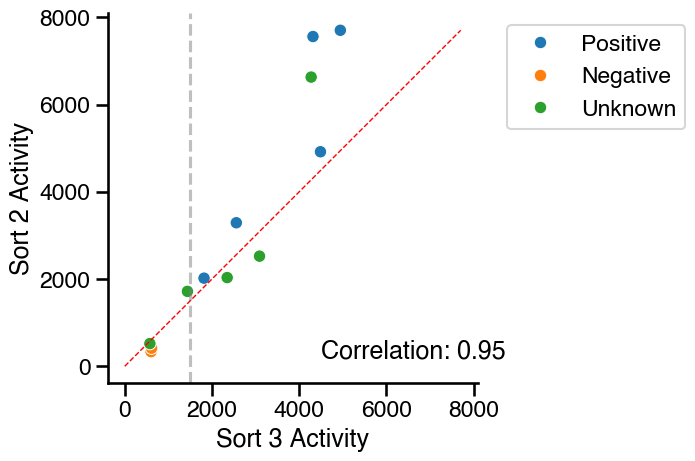

In [53]:
sns.set_context('talk')
sns.scatterplot(data=both_sort_controls, x="Activity_S3_1_S3", y="Activity_S3_1_S2", hue="Control Type")

plt.xlabel("Sort 3 Activity")
plt.ylabel("Sort 2 Activity")

plt.axvline(1500, color='gray', alpha=0.5, linestyle='dashed')
sns.despine()

# Set equal aspect ratio
plt.gca().set_aspect('equal')
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add y = x line
plt.plot([0, max(both_sort_controls["Activity_S3_1_S3"].max(), both_sort_controls["Activity_S3_1_S2"].max())], 
         [0, max(both_sort_controls["Activity_S3_1_S3"].max(), both_sort_controls["Activity_S3_1_S2"].max())], 
         color='red', linestyle='dashed', linewidth=1)

# Add correlation
correlation = both_sort_controls["Activity_S3_1_S3"].corr(both_sort_controls["Activity_S3_1_S2"])
plt.text(x = 4500, y = 200, s = f"Correlation: {correlation:.2f}")
